In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###Предобработка данных

In [ ]:
df = pd.read_csv('athletes.csv')
df.head()

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1
3,521041435,Aaron Cook,MDA,male,1/2/91,1.83,80.0,taekwondo,0,0,0
4,33922579,Aaron Gate,NZL,male,11/26/90,1.81,71.0,cycling,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB


In [ ]:
df.isna().sum()

,0
id,0
name,0
nationality,0
sex,0
dob,1
height,330
weight,659
sport,0
gold,0
silver,0


In [ ]:
#Заполним пропуски в росте и весе медианой
NaN_to_fill = ['weight', 'height']
df[NaN_to_fill] = df[NaN_to_fill].fillna(df[NaN_to_fill].median())
df

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1
3,521041435,Aaron Cook,MDA,male,1/2/91,1.83,80.0,taekwondo,0,0,0
4,33922579,Aaron Gate,NZL,male,11/26/90,1.81,71.0,cycling,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
11533,265605954,Zurian Hechavarria,CUB,female,8/10/95,1.64,58.0,athletics,0,0,0
11534,214461847,Zuzana Hejnova,CZE,female,12/19/86,1.73,63.0,athletics,0,0,0
11535,88361042,di Xiao,CHN,male,5/14/91,1.85,100.0,wrestling,0,0,0
11536,900065925,le Quoc Toan Tran,VIE,male,4/5/89,1.60,56.0,weightlifting,0,0,0


In [ ]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11537 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11537 non-null  int64  
 1   name         11537 non-null  object 
 2   nationality  11537 non-null  object 
 3   sex          11537 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11537 non-null  float64
 6   weight       11537 non-null  float64
 7   sport        11537 non-null  object 
 8   gold         11537 non-null  int64  
 9   silver       11537 non-null  int64  
 10  bronze       11537 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 1.1+ MB


###Импорт и обучение модели

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
X = df[['nationality','height', 'weight', 'sport', 'gold', 'silver', 'bronze']]
X

,nationality,height,weight,sport,gold,silver,bronze
0,ESP,1.72,64.0,athletics,0,0,0
1,KOR,1.68,56.0,fencing,0,0,0
2,CAN,1.98,79.0,athletics,0,0,1
3,MDA,1.83,80.0,taekwondo,0,0,0
4,NZL,1.81,71.0,cycling,0,0,0
...,...,...,...,...,...,...,...
11533,CUB,1.64,58.0,athletics,0,0,0
11534,CZE,1.73,63.0,athletics,0,0,0
11535,CHN,1.85,100.0,wrestling,0,0,0
11536,VIE,1.60,56.0,weightlifting,0,0,0


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
le = LabelEncoder()
ohe = OneHotEncoder()

In [ ]:
le.fit(df['sex'])
y = pd.Series(data = le.transform(df['sex']))
y.head()

,0
0,1
1,0
2,1
3,1
4,1


In [ ]:
cat_ = ['nationality','sport', 'gold', 'silver', 'bronze']
num_ = ['height', 'weight']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', sparse_output=False), cat_),
        ('num', StandardScaler(), num_)])

In [ ]:
df_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X = pd.DataFrame(df_encoded, columns=feature_names)

In [ ]:
model = LogisticRegression()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [ ]:
model.fit(X_train, y_train)
predictions = model.predict_proba(X_test)

In [ ]:
model.score(X_train, y_train)

0.8353017661718496

In [ ]:
model.score(X_test, y_test)

0.8336221837088388

In [ ]:
from sklearn.metrics import roc_curve

In [ ]:
fpr, tpr, thres = roc_curve(y_test, predictions[:, 1])

In [ ]:
for line in zip(fpr, tpr, thres):
  print(line)

(np.float64(0.0), np.float64(0.0), np.float64(inf))
(np.float64(0.0), np.float64(0.000791765637371338), np.float64(0.9999848335019487))
(np.float64(0.0), np.float64(0.026128266033254157), np.float64(0.9983388476665279))
(np.float64(0.0009569377990430622), np.float64(0.026128266033254157), np.float64(0.9981935706491495))
(np.float64(0.0009569377990430622), np.float64(0.050673000791765635), np.float64(0.9953725316422296))
(np.float64(0.0019138755980861245), np.float64(0.050673000791765635), np.float64(0.9953303569339611))
(np.float64(0.0019138755980861245), np.float64(0.0934283452098179), np.float64(0.9904713196645256))
(np.float64(0.003827751196172249), np.float64(0.0934283452098179), np.float64(0.990285572113712))
(np.float64(0.003827751196172249), np.float64(0.11718131433095803), np.float64(0.986020510237878))
(np.float64(0.004784688995215311), np.float64(0.11718131433095803), np.float64(0.9859390479343371))
(np.float64(0.004784688995215311), np.float64(0.12984956452889945), np.float6

In [ ]:
def roc_lib():
  plt.plot(fpr, tpr)
  plt.title('ROC из либ')
  plt.xlabel('FPR')
  plt.ylabel('TPR')

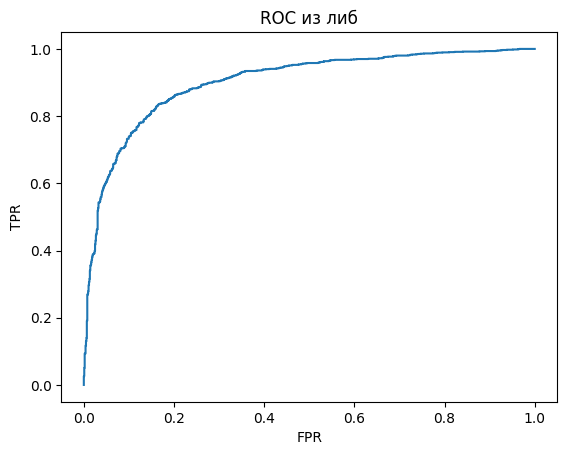

In [ ]:
roc_lib()

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
roc_auc_score(y_test, predictions[:, 1])

np.float64(0.9017369595441855)

###Реализация подсчета метрик TPR, FPR, ROC-кривой "ручками"

In [ ]:
#Порог - значение, которое определяет, как предсказанная моделью
#вероятность будет преобразована в итоговый класс
#Пороги нужно отсортировать от большего к меньшему
thresholds = np.sort(np.unique(predictions[:, 1]))[::-1]
tpr_list = []
fpr_list = []
# Общее количество положительных и отрицательных примеров в y_test
P = np.sum(y_test == 1)
N = np.sum(y_test == 0)
for thres in thresholds:
  tp = 0
  fp = 0
  fn = 0
  tn = 0
  for predicted_prob, actual in zip(predictions[:, 1], y_test):
    if predicted_prob >= thres:
      predicted = 1
    else:
      predicted = 0

    if predicted == 1:
      if actual == 1:
        tp += 1
      else:
        fp += 1
    else:
      if actual == 1:
        fn += 1
      else:
        tn += 1
#Считаем для каждой итерации TPR и FPR с защитой от деления на 0
  tpr = tp / P if P > 0 else 0
  fpr = fp / N if N > 0 else 0

  tpr_list.append(tpr)
  fpr_list.append(fpr)

In [ ]:
def roc_manual():
  plt.plot(fpr_list, tpr_list)
  plt.xlabel('FPR')
  plt.ylabel('TPR')
  plt.title('ROC ручная')

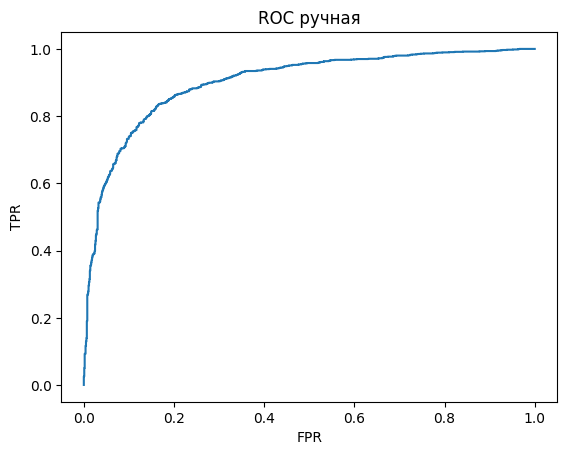

In [ ]:
roc_manual()

Кривая очень похожа на кривую из либы, визуализируем на одном графике

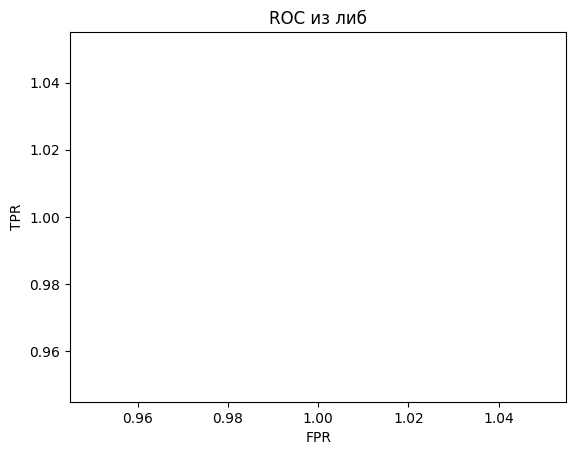

In [ ]:
#но сначала снова инициализируем roc_curve
roc_lib()

In [ ]:
fpr1, tpr1, thres1 = roc_curve(y_test, predictions[:, 1])

In [ ]:
def roc_comparison():
  plt.plot(fpr1, tpr1, label = 'Из либ')
  plt.plot(fpr_list, tpr_list, label = 'Ручная')
  plt.xlabel('FPR')
  plt.ylabel('TPR')
  plt.legend()
  plt.show()

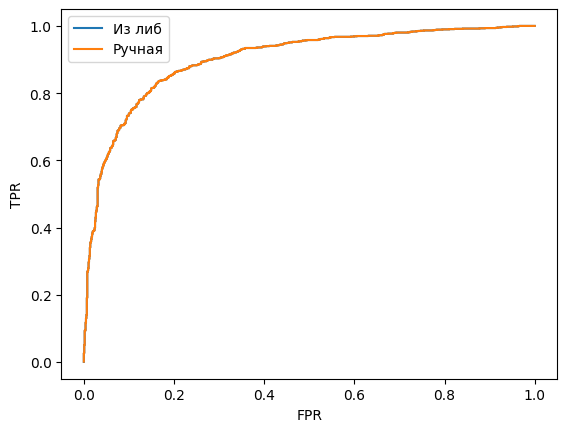

In [ ]:
roc_comparison()

Кривые совпадают

###Построение precision-recall графика вручную

In [ ]:
thresholds = np.sort(np.unique(predictions[:, 1]))
recall_list = []
precision_list = []
# Общее количество положительных примеров в y_test
P = np.sum(y_test == 1)
for thres in thresholds:
  tp = 0
  fp = 0
  fn = 0
  tn = 0
  for predicted_prob, actual in zip(predictions[:, 1], y_test):
    if predicted_prob >= thres:
      predicted = 1
    else:
      predicted = 0

    if predicted == 1:
      if actual == 1:
        tp += 1
      else:
        fp += 1
    else:
      if actual == 1:
        fn += 1
      else:
        tn += 1

# Вычисляем recall (TPR)
  recall = tp / P if P > 0 else 0
  precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0

  recall_list.append(recall)
  precision_list.append(precision)

In [ ]:
def pr_manual():
  plt.plot(recall_list, precision_list)
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title('Precision-recall')

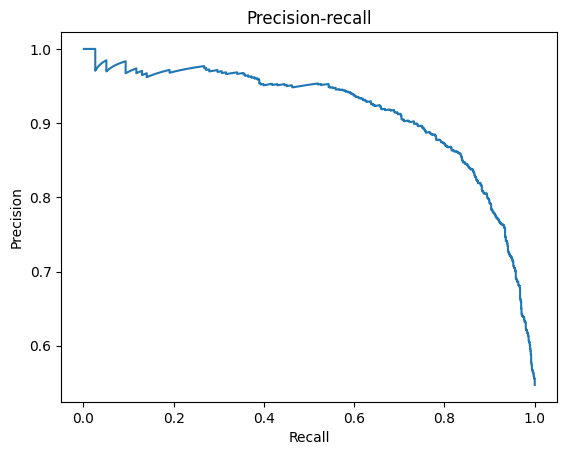

In [ ]:
pr_manual()

In [ ]:
from sklearn.metrics import auc

In [ ]:
#Для себя - можно попробовать метод трапеций (?)
auc(recall_list, precision_list)

np.float64(0.913661528912771)

- Площадь под кривой PR auc отражает способность модели предсказывать классы в условиях дисбаланса. Чем выше значение auc - тем лучше модель справляется. В данном случае auc = 0.91, модель можно назвать хорошей.
- ROC-кривая может проходить ниже диагонали, это означает, что модель предсказывает результаты, которые противоположны истинным.